In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
depth_gt_1 = pd.read_csv("saved_files/df_boyas_depth_gt_1.csv").rename(columns={"Chl": "Chl_gt_1"})
depth_lt_1 = pd.read_csv("saved_files/df_boyas_depth_lt_1.csv").rename(columns={"Chl": "Chl_lt_1"})
depth_lt_2 = pd.read_csv("saved_files/df_boyas_depth_lt_2.csv").rename(columns={"Chl": "Chl_lt_2"})
depth_gt_1_imida = pd.read_csv("saved_files/df_boyas_imida_depth_gt_1.csv").rename(columns={"Chl": "Chl_gt_1"})
depth_lt_1_imida = pd.read_csv("saved_files/df_boyas_imida_depth_lt_1.csv").rename(columns={"Chl": "Chl_lt_1"})
depth_lt_2_imida = pd.read_csv("saved_files/df_boyas_imida_depth_lt_2.csv").rename(columns={"Chl": "Chl_lt_2"})

In [135]:
df_upct = depth_gt_1.merge(depth_lt_1, on=["Date", "Buoy"]).merge(depth_lt_2, on=["Date", "Buoy"])
df_imida = depth_gt_1_imida.merge(depth_lt_1_imida, on=["Date", "Buoy"]).merge(depth_lt_2_imida, on=["Date", "Buoy"])
df_imida["Buoy"] = df_imida["Buoy"].str.replace(r"CTD-E", "CTD", regex=True)


In [137]:
def add_differences(df):
    df["gt_1 - lt_1"] = df["Chl_gt_1"] - df["Chl_lt_1"]
    df["gt_1 - lt_2"] = df["Chl_gt_1"] - df["Chl_lt_2"]
    df["lt_2 - lt_1"] = df["Chl_lt_2"] - df["Chl_lt_1"]
    df["Date"] = pd.to_datetime(df["Date"])
    return df

In [138]:
df_upct = add_differences(df_upct)
df_imida = add_differences(df_imida)

In [146]:
df_merge = df_upct.merge(df_imida, on=["Date","Buoy"], how="inner", suffixes=("_upct","_imida"))
df_merge["gt_1_diff"] = df_merge["Chl_gt_1_upct"] - df_merge["Chl_gt_1_imida"]
df_merge["lt_1_diff"] = df_merge["Chl_lt_1_upct"] - df_merge["Chl_lt_1_imida"]
df_merge["lt_2_diff"] = df_merge["Chl_lt_2_upct"] - df_merge["Chl_lt_2_imida"]

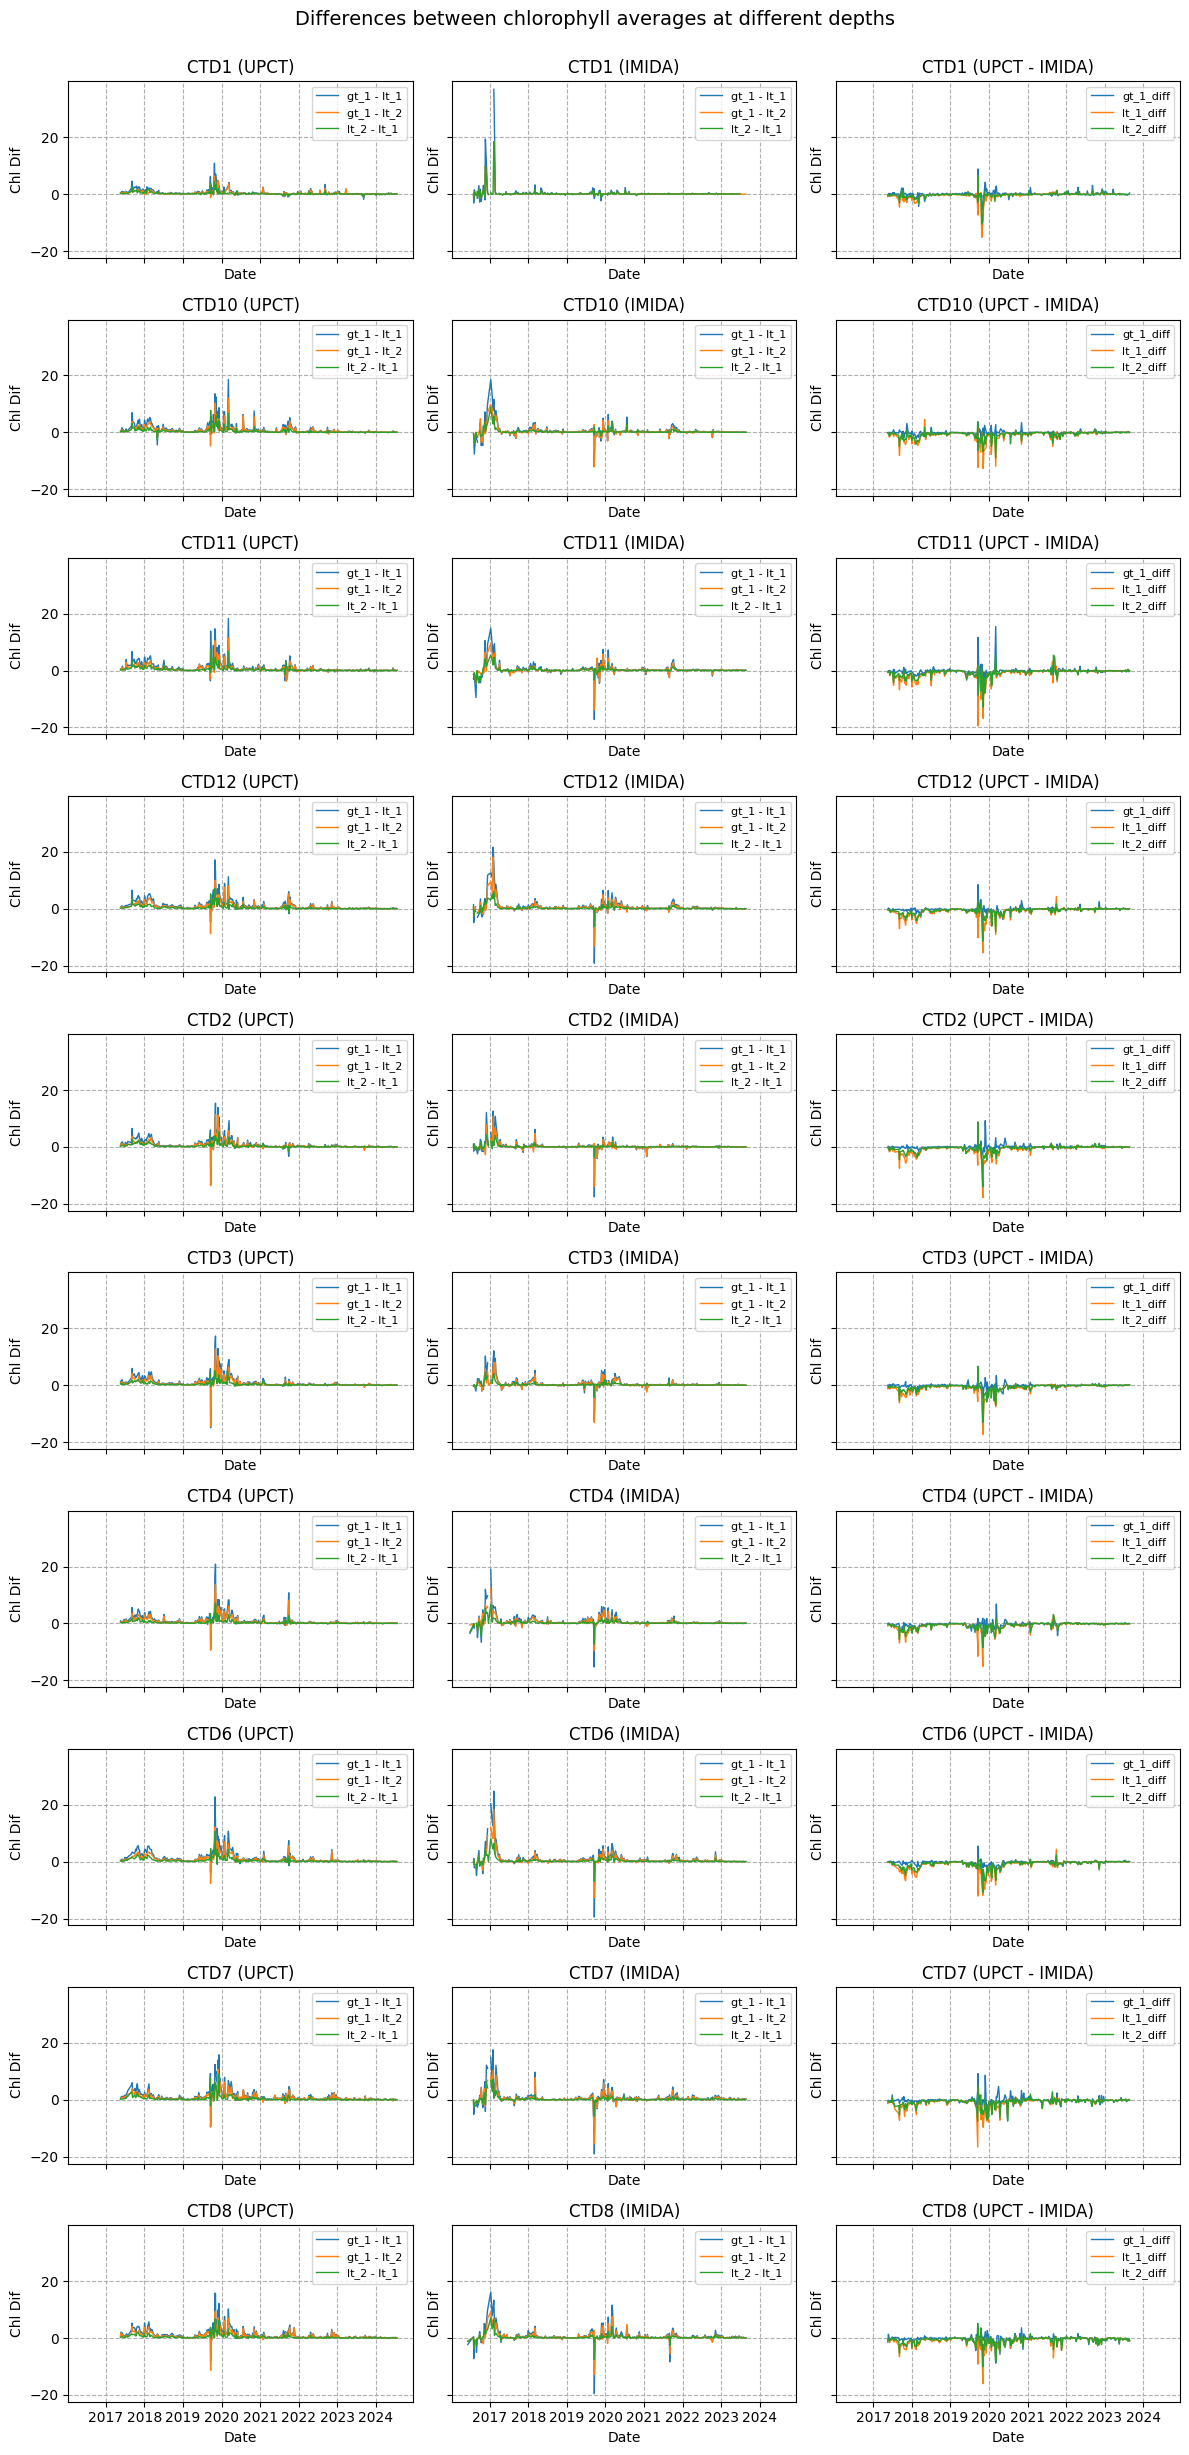

In [149]:
def plot_buoys(df1, df2, df3):
    buoys= sorted(df1["Buoy"].unique())
    n_buoys = len(buoys)
    columns = ['gt_1 - lt_1', 'gt_1 - lt_2', 'lt_2 - lt_1']

    fig, ax = plt.subplots(figsize=(12,2.5*n_buoys), nrows=n_buoys, ncols=3, sharey=True, sharex=True)
    #ax = axes.flatten()
   
    col_index = 0
    for i, buoy in enumerate(buoys):
        df_to_plot = df1.loc[df1["Buoy"]==buoy]
        for col in columns:
            if col in df_to_plot.columns:
                if col != 'Date':
                    linestyle = '-'
                    ax[i, col_index].plot(df_to_plot['Date'], df_to_plot[col], label=col, linewidth=1, linestyle = linestyle)

        ax[i, col_index].set_title(f'{buoy} (UPCT)')
        ax[i, col_index].set_xlabel('Date')
        ax[i, col_index].set_ylabel('Chl Dif')
        ax[i, col_index].legend(loc="upper right", fontsize = 8)
        ax[i, col_index].grid(linestyle='--')

    col_index = 1
    for i, buoy in enumerate(buoys):
        df_to_plot = df2.loc[df2["Buoy"]==buoy]
        for col in columns:
            if col in df_to_plot.columns:
                if col != 'Date':
                    linestyle = '-'
                    ax[i, col_index].plot(df_to_plot['Date'], df_to_plot[col], label=col, linewidth=1, linestyle = linestyle)

        ax[i, col_index].set_title(f'{buoy} (IMIDA)')
        ax[i, col_index].set_xlabel('Date')
        ax[i, col_index].set_ylabel('Chl Dif')
        ax[i, col_index].legend(loc="upper right", fontsize = 8)
        ax[i, col_index].grid(linestyle='--')

    col_index = 2
    columns = ['gt_1_diff', 'lt_1_diff', 'lt_2_diff']
    for i, buoy in enumerate(buoys):
        df_to_plot = df3.loc[df3["Buoy"]==buoy]
        for col in columns:
            if col in df_to_plot.columns:
                if col != 'Date':
                    linestyle = '-'
                    ax[i, col_index].plot(df_to_plot['Date'], df_to_plot[col], label=col, linewidth=1, linestyle = linestyle)

        ax[i, col_index].set_title(f'{buoy} (UPCT - IMIDA)')
        ax[i, col_index].set_xlabel('Date')
        ax[i, col_index].set_ylabel('Chl Dif')
        ax[i, col_index].legend(loc="upper right", fontsize = 8)
        ax[i, col_index].grid(linestyle='--')

    fig.suptitle("Differences between chlorophyll averages at different depths", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_buoys(df_upct, df_imida, df_merge)
